In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from umap import UMAP
# import trimap
import pacmap

%matplotlib inline

In [3]:
nb_classes = 10
dropout = 0.5

# Build very simple neural network with 2 hidden layers
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation="relu"),
    Dropout(dropout),
    Dense(64, activation="relu"),
    Dropout(dropout),
    Dense(nb_classes, activation="softmax")
])


model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5 / 6)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
network_history = model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(X_val, Y_val),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6872 - loss: 0.8831 - val_accuracy: 0.8342 - val_loss: 0.4642
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8012 - loss: 0.5751 - val_accuracy: 0.8543 - val_loss: 0.4031
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.5152 - val_accuracy: 0.8677 - val_loss: 0.3744
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8330 - loss: 0.4792 - val_accuracy: 0.8739 - val_loss: 0.3535
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8388 - loss: 0.4622 - val_accuracy: 0.8663 - val_loss: 0.3542
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8429 - loss: 0.4436 - val_accuracy: 0.8789 - val_loss: 0.3445
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8483 - loss: 0.4297 - val_accuracy: 0.8753 - val_loss: 0.3472
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.4194 - val_accuracy: 0.

In [6]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

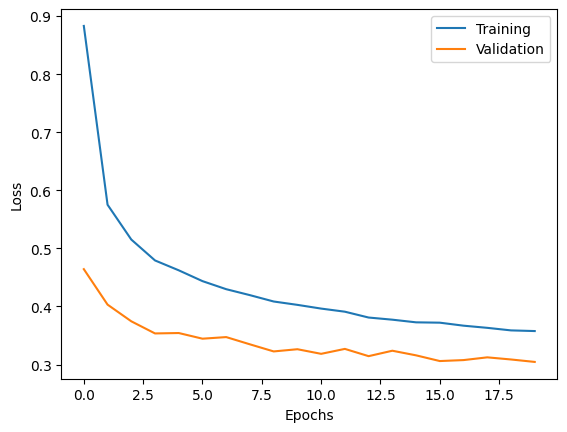

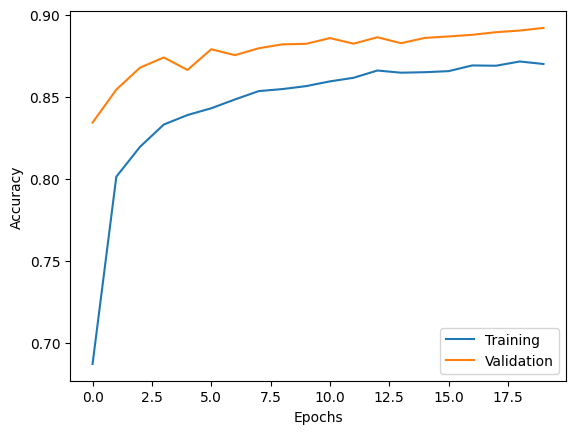

In [7]:
plot_history(network_history)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

In [9]:
inp = Input(shape=(784,))
x = inp
intermediate = []
for layer in model.layers:
    x = layer(x)
    if isinstance(layer, Dense):
        intermediate.append(x)

layer_outputs_model = Model(inputs=inp, outputs=intermediate)
print(f"Outputs captured: {len(intermediate)}")

Outputs captured: 3


In [10]:
N_TRAIN = 5000
N_TEST = 2000
rng = np.random.default_rng(42)

y_train_int = np.argmax(Y_train, axis=1)
y_test_int = np.argmax(Y_test, axis=1)

idx_train = rng.choice(len(X_train), N_TRAIN, replace=False)
idx_test = rng.choice(len(X_test), N_TEST, replace=False)

X_tr, y_tr = X_train[idx_train], y_train_int[idx_train]
X_te, y_te = X_test[idx_test], y_test_int[idx_test]

h1_tr, h2_tr, _ = layer_outputs_model(X_tr, training=False)
h1_te, h2_te, _ = layer_outputs_model(X_te, training=False)

h1_tr, h2_tr = h1_tr.numpy(), h2_tr.numpy()
h1_te, h2_te = h1_te.numpy(), h2_te.numpy()

print(f"Train: X={X_tr.shape}, h1={h1_tr.shape}, h2={h2_tr.shape}")
print(f"Test : X={X_te.shape}, h1={h1_te.shape}, h2={h2_te.shape}")

Train: X=(5000, 784), h1=(5000, 256), h2=(5000, 64)
Test : X=(2000, 784), h1=(2000, 256), h2=(2000, 64)


In [11]:
PAL = np.array(sns.color_palette("tab10", 10))

def scatter_emb(ax, emb, labels, title):
    for c in range(10):
        mask = labels == c
        ax.scatter(emb[mask, 0], emb[mask, 1], s=1.5, alpha=0.55, color=PAL[c])
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])


def add_legend(fig, ncol=10):
    patches = [mpl.patches.Patch(color=PAL[i], label=str(i)) for i in range(10)]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=ncol,
        fontsize=8,
        bbox_to_anchor=(0.5, -0.02),
    )

In [12]:
inputs_tr = {"raw": X_tr, "h1": h1_tr, "h2": h2_tr}
sources = ["raw", "h1", "h2"]
# methods = ["t-SNE", "UMAP", "TriMAP", "PaCMAP"]
methods = ["t-SNE", "UMAP", "PaCMAP"]

embeddings_tr = {}
umap_models = {}

for src, data in inputs_tr.items():
    print(f"--- {src} ---")

    embeddings_tr[(src, "t-SNE")] = TSNE(n_components=2, random_state=42).fit_transform(data)
    print("t-SNE done")

    umap_m = UMAP(n_components=2, random_state=42)
    embeddings_tr[(src, "UMAP")] = umap_m.fit_transform(data)
    umap_models[src] = umap_m
    print("UMAP done")

    # embeddings_tr[(src, "TriMAP")] = trimap.TRIMAP().fit_transform(data)
    # print("TriMAP done")

    embeddings_tr[(src, "PaCMAP")] = pacmap.PaCMAP(n_components=2).fit_transform(data)
    print("PaCMAP done")

--- raw ---
t-SNE done


c:\Users\User\miniconda3\envs\umisi\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
PaCMAP done
--- h1 ---
t-SNE done


c:\Users\User\miniconda3\envs\umisi\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
PaCMAP done
--- h2 ---
t-SNE done


c:\Users\User\miniconda3\envs\umisi\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
PaCMAP done


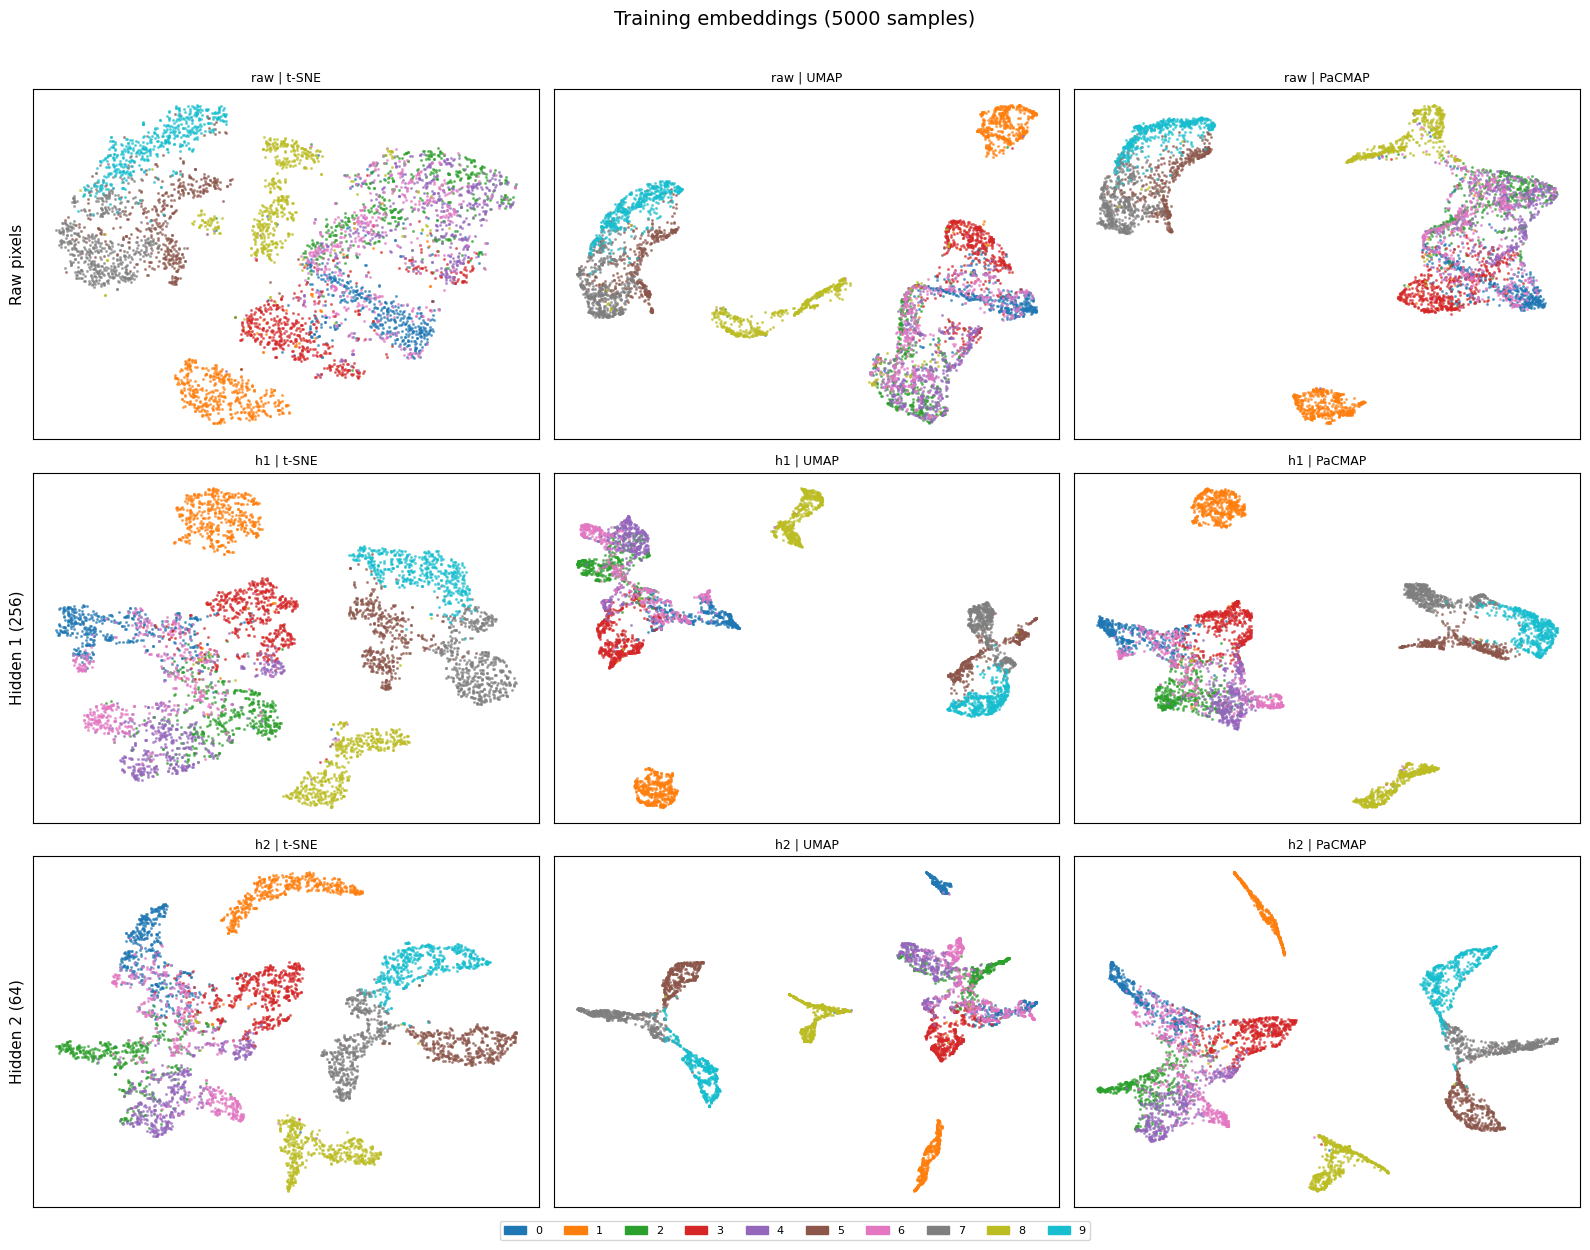

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

row_labels = {"raw": "Raw pixels", "h1": "Hidden 1 (256)", "h2": "Hidden 2 (64)"}

for r, src in enumerate(sources):
    for c, m in enumerate(methods):
        scatter_emb(axes[r, c], embeddings_tr[(src, m)], y_tr, f"{src} | {m}")
    axes[r, 0].set_ylabel(row_labels[src], fontsize=11, labelpad=6)

fig.suptitle("Training embeddings (5000 samples)", fontsize=14, y=1.01)
add_legend(fig)
plt.tight_layout()
plt.show()

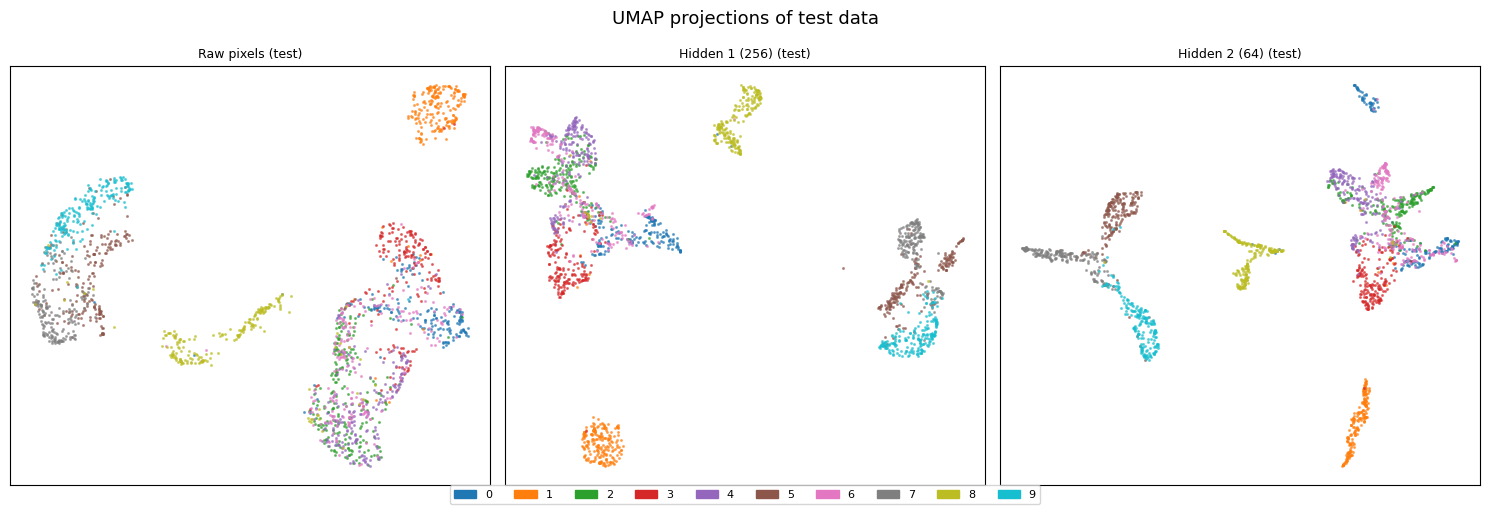

In [14]:
inputs_te = {"raw": X_te, "h1": h1_te, "h2": h2_te}
embeddings_te_umap = {
    src: umap_models[src].transform(inputs_te[src]) for src in sources
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for c, src in enumerate(sources):
    scatter_emb(axes[c], embeddings_te_umap[src], y_te, f"{row_labels[src]} (test)")
fig.suptitle("UMAP projections of test data", fontsize=13)
add_legend(fig)
plt.tight_layout()
plt.show()